In [1]:
import torch
import json
from ptlpinns.models import model, transfer
from ptlpinns.perturbation import LPM, standard, LKV
from ptlpinns.odes import forcing, numerical, equations
import numpy as np
import math
import matplotlib.pyplot as plt

/home/jovyan/PTL-PINNs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load model

In [2]:
name = "undamped_k12"

undamped_path = f"/home/jovyan/PTL-PINNs/ptlpinns/models/train/{name}"
undamped_name = f"model_{name}.pth"
undamped_model, training_log = model.load_model(undamped_path, undamped_name)

12 True True True 1.0 16 [256, 256, 512]


### Problem definition

The Lotka–Volterra system is written in perturbation form as
$$x = 1 + \varepsilon\,\xi, \quad y = 1 + \varepsilon\,\eta.$$

**Fixed scaled IC $(\xi_0, \eta_0)$.**  The physical IC is
$x_0 = 1 + \varepsilon\,\xi_0$, $y_0 = 1 + \varepsilon\,\eta_0$, so the
amplitude grows with $\varepsilon$ and the truncation error can be compared
against the reference power law $\varepsilon^{p_{\max}}$.

The match is expected in the **truncation-dominated regime**
($\varepsilon \gtrsim 0.4$).  At smaller $\varepsilon$ the error plateaus
because the PTL-PINN basis floor dominates.

In [3]:
t_span = (0, 10)
N = 500
t_eval = np.linspace(t_span[0], t_span[1], N)

alpha = 0.2
p_max = 5

# Fixed scaled IC
xi0_fixed = 1.18
eta0_fixed = -0.1

# High-accuracy reference: (N-1)*REFINE+1 output points, compare every REFINE-th
REFINE = 1000

# Epsilon sweep — truncation-dominated regime (same spirit as undamped sweep)
epsilon_values = np.arange(0.05, 2.0, 0.10)

In [4]:
len(epsilon_values)

20

### Compute latent representations

In [5]:
H_dict = transfer.compute_H_dict(undamped_model, N=N, bias=True, t_span=t_span)

### Epsilon sweep

In [6]:
lpm_maes = []

for epsilon in epsilon_values:
    x0 = 1 + epsilon * xi0_fixed
    y0 = 1 + epsilon * eta0_fixed
    ode = equations.lv_normalized(alpha)

    w_sol = []
    _, perturbation_solution, _ = transfer.compute_perturbation_solution_LKV(
        beta_list=[epsilon],
        p_list=[p_max],
        ic_list=[[xi0_fixed, eta0_fixed]],
        alpha_list=[alpha],
        H_dict=H_dict,
        t_eval=t_eval,
        training_log=training_log,
        all_p=True,
        comp_time=False,
        w_sol=w_sol,
    )

    # N must match len(t_eval) — calculate_error builds the reference grid from N,
    # while xi_loop comes from perturbation_solution on t_eval.
    err = LKV.calculate_error(
        w_sol, perturbation_solution, epsilon, [alpha],
        t_span, len(t_eval), ode, x0, y0, plot=False, refine=REFINE,
    )
    lpm_maes.append(err[p_max])

### MAE @ $p = p_{\max}$ vs $\varepsilon^{p_{\max}}$ — normalised comparison

Same plot style as `undamped_epsilon_sweep.ipynb`: both curves normalised to
their maximum, log-scaled y-axis, steelblue MAE vs orange $\varepsilon^{p_{\max}}$ reference.

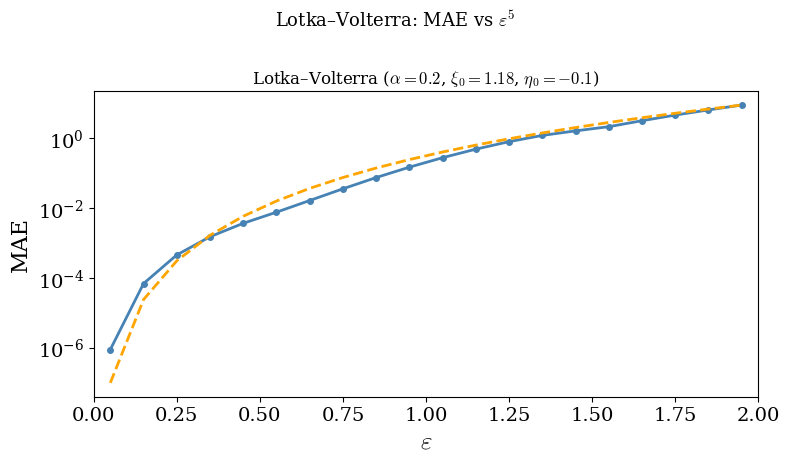

In [7]:
sweep_eps = np.array(epsilon_values)
sweep_maes = np.array(lpm_maes)
sweep_eps_ref = sweep_eps ** p_max

mae_norm = sweep_maes
ref_norm = sweep_eps_ref * np.max(sweep_maes) / np.max(sweep_eps_ref)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(sweep_eps, mae_norm, "o-", linewidth=2, markersize=4,
        color="steelblue", label=rf"MAE @ $p={p_max}$")
ax.plot(sweep_eps, ref_norm, "--", linewidth=2,
        color="orange", label=rf"$\varepsilon^{{{p_max}}}$")


ax.set_title(
    rf"Lotka–Volterra ($\alpha={alpha}$, $\xi_0={xi0_fixed}$, $\eta_0={eta0_fixed}$)",
    fontsize=12,
)
ax.set_yscale("log")
ax.set_xlim(0, 2.0)
ax.tick_params(axis="both", labelsize=14)
ax.set_xlabel(r"$\varepsilon$", fontsize=18)
ax.set_ylabel("MAE", fontsize=16)
#ax.grid(True, alpha=0.3, which="both")
#ax.legend(frameon=False, fontsize=10, loc="upper left")

fig.suptitle(
    rf"Lotka–Volterra: MAE vs $\varepsilon^{{{p_max}}}$",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()